In [1]:
import scipy.io as scio
import numpy as np
import os 
from glob import *
import pandas as pd
import random
from matplotlib import pyplot as plt
import nibabel as nib
from sklearn.manifold import TSNE
import matplotlib.font_manager as font_manager
import seaborn as sns

In [7]:
roi_networks = ['DMN1','DMN2','DMN3','DMN4','SMN1','SMN2','SMN3','VIS1','VIS2','VIS3','VIS4',"SAN1","SAN2","SAN3","SAN4"\
                ,"SAN5","SAN6","SAN7","DAN1","DAN2","DAN3"
          ,"DAN4","FPN1","FPN2","FPN3","FPN4","LN1","LN2","LN3","LN4","CE1","CE2"]
name_scan = ['CTR','PAT1','PAT2','PAT3','PAT4','PAT5']
network32_label = ['DMN','SMN','VIS','SAN','DAN','FPN','LN','CE']
colormap = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', \
            '#e377c2', '#7f7f7f']

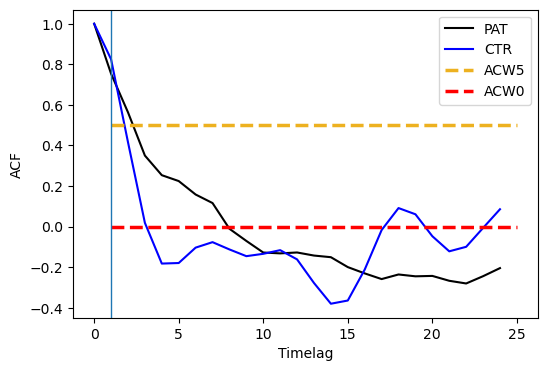

In [124]:
if __name__=="__main__":

    rootpath = 'F:\Matlab\Work\Stroke15_followup\Results\\Network32_Denoised_Timeseries'
    scan_times = ['First','Second','Third','Fourth','Fifth']
    n_subj = 15
    int_multi_scans = {}
    int_multi_scans['Subj'] = []
    int_multi_scans['Time_of_Scan'] = []
    int_multi_scans['Roi_of_Network'] = []
    int_multi_scans['INT'] = []
    int_multi_scans['INT5']=[]
    int_multi_scans['acfstrength01'] = []
    int_multi_scans['ac1'] = []
    int_multi_scans['acfstrength05'] = []
    int_multi_scans['acfstrength00'] = []
    
    
    for num, time in enumerate(scan_times): 
        for i in range(n_subj):
            if  time == 'Zeros': timeseries_path = os.path.join(rootpath,time,'Sub_0'+str(i+16)+'.txt')
            elif i < 9:
                timeseries_path = os.path.join(rootpath,time,'Sub_00'+str(i+1)+'.txt')
            else:
                timeseries_path = os.path.join(rootpath,time,'Sub_0'+str(i+1)+'.txt')
            timeseries = np.loadtxt(timeseries_path)          
            # # print(intrinic_timescale0(timeseries[:,0]))
            autocorr = stattools.acf(timeseries[:,0],nlags = 1000)
            # print(autocorr[1])
            # print()
            if i == 6:
                fig, ax = plt.subplots(figsize=(6, 4))
                plt.plot(range(25),autocorr[:25],color = 'black',label = 'PAT')
                plt.plot(range(25),autocorr_ctr[:25],color = 'blue',label = 'CTR')
                plt.plot([i+1 for i in range(25)],[0.5 for i in range(25)],'--',color = '#EDB120',linewidth=2.5,  label='ACW5')
                plt.plot([i+1 for i in range(25)],[i*0 for i in range(25)],'r--',linewidth=2.5,label='ACW0')
                plt.legend()
                plt.axvline(1,linewidth=1, label ='AC1')
                plt.ylabel('ACF')
                plt.xlabel('Timelag')
            # time_series = timeseries[num*200:(num+1)*200,:]
            # print(time_series.shape)
            # break
        break

In [ ]:
# np.arange(0,200,1)

from Utils.dynamic_measures import intrinsic_timescale_expfit,intrinic_timescale00,intrinic_timescale01,intrinic_timescale05

from Utils.dynamic_measures import acfstrength00,acfstrength01,acfstrength05
from Utils.dynamic_measures import ac1,hurst,CR_RAD
# from Utils.hopf import simulate_hopf
measure_funcs = {
    'INTe':   intrinsic_timescale_expfit,
    'Int00':  intrinic_timescale00,
    'Int01':  intrinic_timescale01,
    'Int05':  intrinic_timescale05,
    'Acf00':  acfstrength00,
    'Acf01':  acfstrength01,
    'Acf05':  acfstrength05,
    'cRAD':   lambda x: CR_RAD(x, do_abs=True),
    'RAD':    lambda x: CR_RAD(x, do_abs=False),
    'Ac1':    ac1,
    'Std':    np.std,
    'Hurst':  hurst,
}

In [ ]:
if __name__=="__main__":

    rootpath = 'F:\Matlab\Work\Stroke15_followup\Results\\Network32_Denoised_Timeseries'
    scan_times = ['Zeros','First','Second','Third','Fourth','Fifth']
    n_subj = 15
    int_multi_scans = {}
    int_multi_scans['Subj'] = []
    int_multi_scans['Time_of_Scan'] = []
    int_multi_scans['Roi_of_Network'] = []
    
    int_multi_scans['ac1'] = []

    int_multi_scans['INT_{0}'] = []
    int_multi_scans['INT_{0.1}'] = []
    int_multi_scans['INT_{0.5}'] = []
    int_multi_scans['ACF_{0}'] = []
    int_multi_scans['ACF_{0.1}'] = []
    int_multi_scans['ACF_{0.5}'] = []
    
    for num, time in enumerate(scan_times): 
        for i in range(n_subj):
            if  time == 'Zeros': timeseries_path = os.path.join(rootpath,time,'Sub_0'+str(i+16)+'.txt')
            elif i < 9:
                timeseries_path = os.path.join(rootpath,time,'Sub_00'+str(i+1)+'.txt')
            else:
                timeseries_path = os.path.join(rootpath,time,'Sub_0'+str(i+1)+'.txt')
            timeseries = np.loadtxt(timeseries_path)          
            
            for j, roi in enumerate(roi_networks):
                int_multi_scans['Subj'].append(i+1)
                int_multi_scans['Time_of_Scan'].append(name_scan[num])
                int_multi_scans['Roi_of_Network'].append(roi)
                int_multi_scans['INT_{0}'].append(intrinic_timescale0(timeseries[:,j]))
                int_multi_scans['INT_{0.1}'].append(intrinic_timescale1(timeseries[:,j]))
                int_multi_scans['INT_{0.5}'].append(intrinic_timescale5(timeseries[:,j]))
                int_multi_scans['ACF_{0}'].append(acfstrength00(timeseries[:,j]))
                int_multi_scans['ACF_{0.1}'].append(acfstrength01(timeseries[:,j]))
                int_multi_scans['ac1'].append(ac1(timeseries[:,j]))
                int_multi_scans['ACF_{0.5}'].append(acfstrength05(timeseries[:,j]))

In [225]:
int_multi_scans_df = pd.DataFrame(int_multi_scans)
int_multi_scans_df.to_csv('all_ica_int.csv', index = False)
int_multi_scans_df

,Subj,Time_of_Scan,Roi_of_Network,ac1,INT_{0},INT_{0.1},INT_{0.5},ACF_{0},ACF_{0.1},ACF_{0.5}
0,1,CTR,DMN1,0.825016,1.259987,1.241329,0.825016,3.10,2.80,1.80
1,1,CTR,DMN2,0.835495,1.343271,1.283440,0.835495,3.29,2.90,1.87
2,1,CTR,DMN3,0.864086,1.535735,1.535735,1.390134,3.53,3.17,2.07
3,1,CTR,DMN4,0.849368,1.445355,1.445355,0.849368,3.43,3.03,1.98
4,1,CTR,SMN1,0.832462,1.425559,1.425559,0.832462,3.74,3.15,1.92
...,...,...,...,...,...,...,...,...,...,...
2875,15,PAT5,LN2,0.333457,6.811402,2.809323,0.000000,38.83,10.71,0.76
2876,15,PAT5,LN3,0.799207,2.323760,2.263123,1.386555,8.10,6.01,2.43
2877,15,PAT5,LN4,0.664755,1.547767,1.466064,0.664755,7.06,4.28,1.96
2878,15,PAT5,CE1,0.773295,2.696168,2.682235,1.906469,7.12,6.05,3.02


## global

In [227]:
global_int = {}
global_int['Subj'] = []
global_int['Time_of_Scan'] = []
global_int['INT_{0}'] = []
global_int['INT_{0.1}'] = []
global_int['INT_{0.5}'] = []
global_int['ACF_{0}'] = []
global_int['ACF_{0.1}'] = []
global_int['ACF_{0.5}'] = []
global_int['ac1'] = []


for num, time in enumerate(scan_times):
    for i in range(n_subj):
        int_attime_df = int_multi_scans_df[int_multi_scans_df['Time_of_Scan'] == name_scan[num]]       
        int_global = int_attime_df[int_attime_df['Subj'] == i+1]
        # print(np.mean(int_global['INT'].values))
        global_int['Time_of_Scan'].append(name_scan[num])
        global_int['Subj'].append(i)
        global_int['INT_{0}'].append(np.mean(int_global['INT_{0}'].values))
        global_int['INT_{0.1}'].append(np.mean(int_global['INT_{0.1}'].values))
        global_int['INT_{0.5}'].append(np.mean(int_global['INT_{0.5}'].values))
        global_int['ACF_{0.1}'].append(np.mean(int_global['ACF_{0.1}'].values)) 
        global_int['ac1'].append(np.mean(int_global['ac1'].values)) 
        global_int['ACF_{0.5}'].append(np.mean(int_global['ACF_{0.5}'].values)) 
        global_int['ACF_{0}'].append(np.mean(int_global['ACF_{0}'].values)) 
global_int_df = pd.DataFrame(global_int)
global_int_df

,Subj,Time_of_Scan,INT_{0},INT_{0.1},INT_{0.5},ACF_{0},ACF_{0.1},ACF_{0.5},ac1
0,0,CTR,1.448699,1.422717,1.082604,3.530938,3.108125,1.977813,0.846588
1,1,CTR,1.650556,1.604116,1.128074,4.579063,3.688438,2.078750,0.851024
2,2,CTR,1.527095,1.503615,1.162163,3.851875,3.333750,2.029375,0.850803
3,3,CTR,2.167078,2.122382,1.613995,5.489687,4.631562,2.553438,0.891721
4,4,CTR,1.518476,1.499057,1.172900,3.598125,3.210625,2.051875,0.855183
...,...,...,...,...,...,...,...,...,...
85,10,PAT5,2.630293,2.207510,1.413675,8.878438,5.540938,2.631563,0.700415
86,11,PAT5,7.505398,6.513032,2.176066,32.443438,20.326875,4.091250,0.454908
87,12,PAT5,5.377105,4.537107,1.373742,21.321563,13.622500,2.565937,0.618793
88,13,PAT5,6.734221,5.694987,1.458277,28.039688,18.699063,2.869688,0.672462


In [214]:
global_int_df.to_csv('global_int_df.csv',index = False)

## network

In [ ]:
net_int = {}
net_int['Subj'] = []
net_int['Time_of_Scan'] = []
net_int['Net'] = []
net_int['INT_{0}'] = []
net_int['INT_{0.1}'] = []
net_int['INT_{0.5}'] = []
net_int['ACF_{0}'] = []
net_int['ACF_{0.1}'] = []
net_int['ACF_{0.5}'] = []
net_int['ac1'] = []

for num, time in enumerate(scan_times):
    for i in range(n_subj):
        int_attime_df = int_multi_scans_df[int_multi_scans_df['Time_of_Scan'] == name_scan[num]]       
        int_at_time_subj_df = int_attime_df[int_attime_df['Subj'] == i+1]
        # print(np.mean(int_global['INT'].values))
        for net in network32_label:
            net_ind = [netss.startswith(net) for netss in int_at_time_subj_df['Roi_of_Network']]
            # print(np.mean(int_at_time_subj_df[net_ind]['INT'].values))
            net_int['Subj'].append(i+1)
            net_int['Time_of_Scan'].append(name_scan[num])
            net_int['Net'].append(net)
            net_int['INT'].append(np.mean(int_at_time_subj_df[net_ind]['INT'].values))
            net_int['INT5'].append(np.mean(int_at_time_subj_df[net_ind]['INT5'].values))
            net_int['acfstrength01'].append(np.mean(int_at_time_subj_df[net_ind]['acfstrength01'].values)) 
            net_int['ac1'].append(np.mean(int_at_time_subj_df[net_ind]['ac1'].values)) 
            net_int['acfstrength05'].append(np.mean(int_at_time_subj_df[net_ind]['acfstrength05'].values)) 
            net_int['acfstrength00'].append(np.mean(int_at_time_subj_df[net_ind]['acfstrength00'].values)) 

net_int_df = pd.DataFrame(net_int)
net_int_df      
net_int_df.to_csv('net_int_df_all_measure.csv', index = False)

,Subj,Time_of_Scan,Net,INT,INT5,acfstrength00,ac1,acfstrength05,acfstrength01
0,1,CTR,DMN,1.396087,0.975003,3.337500,0.843491,1.930000,2.975000
1,1,CTR,SMN,1.479894,1.033909,3.770000,0.843626,1.990000,3.230000
2,1,CTR,VIS,1.558577,1.152915,3.590000,0.864569,2.105000,3.232500
3,1,CTR,SAN,1.476508,1.220597,3.718571,0.847920,1.995714,3.185714
4,1,CTR,DAN,1.411291,1.105592,3.452500,0.841622,1.950000,3.087500
...,...,...,...,...,...,...,...,...,...
715,15,PAT5,SAN,8.139374,2.255926,29.120000,0.713674,3.937143,21.644286
716,15,PAT5,DAN,4.380530,1.154792,23.547500,0.623148,2.445000,10.670000
717,15,PAT5,FPN,8.563622,2.369149,32.360000,0.625643,4.587500,23.142500
718,15,PAT5,LN,7.221512,1.307561,31.125000,0.631369,2.715000,19.292500


## track of individual INT

In [ ]:
pat_global_int_df = global_int_df[global_int_df['Time_of_Scan'].isin( ['PAT1','PAT3', 'PAT5'])]
pat_global_int_df

scan_times3 =  ['PAT1','PAT3', 'PAT5']
individual_global_int = pat_global_int_df.groupby('Subj',sort = False)
for subj, individual_global_int_df in individual_global_int:
    # print(subj, individual_global_int_df)
    subj_int = individual_global_int_df['INT'].values
    print(subj_int)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(1,6,2), subj_int, marker = '.',  linewidth = 2.2, linestyle='-',label = f'{subj}')
    font_prop = font_manager.FontProperties(size=14)
    ax.set_xlabel('Time of Scan',fontsize=27)
    ax.set_ylabel('Intrinsic Timescale',fontsize=27)
    ax.set_title('Individual INT across six Month post-stroke',fontsize=16)
    ax.set_xticks(np.arange(1,6,2))
    ax.set_xticklabels(scan_times3)
    ax.legend(prop = font_prop)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# font_prop = font_manager.FontProperties(size=18)

# plt.grid()

In [ ]:
pat_global_int_df = global_int_df[global_int_df['Time_of_Scan'].isin( ['PAT1','PAT3', 'PAT5'])]
pat_global_int_df
poor_recovery = [0,4,5,6,7,8,9,11,14]
good_recovery = [1,2,3,10,12,13]
scan_times3 =  ['PAT1','PAT3', 'PAT5']
fig1, ax1 = plt.subplots(figsize=(6, 4))
fig2, ax2 = plt.subplots(figsize=(6, 4))
individual_global_int = pat_global_int_df.groupby('Subj',sort = False)
for subj, individual_global_int_df in individual_global_int:
    # print(subj, individual_global_int_df)
    subj_int = individual_global_int_df['INT'].values
    # print(subj_int)
    if subj in good_recovery:
        ax1.plot(np.arange(1,6,2), subj_int, marker = '.', linewidth = 2.2, linestyle='-',label = f'{subj}')
        fig1, ax1 = plt.subplots(figsize=(6, 4))
        font_prop = font_manager.FontProperties(size=14)
        ax1.set_xlabel('Time of Scan',fontsize=16)
        ax1.set_ylabel('Intrinsic Timescale',fontsize=16)
        ax1.set_title('Good Recovery Individuals',fontsize=16)
        ax1.set_xticks(np.arange(1,6,2),scan_times3,fontsize=14)
        ax1.set_yticks(np.arange(4,18,2),np.arange(4,18,2),fontsize=14)
        ax1.legend(prop = font_prop)
    if subj in poor_recovery:
        ax2.plot(np.arange(1,6,2), subj_int, marker = '.',  linewidth = 2.2, linestyle='-',label = f'{subj}')
        font_prop = font_manager.FontProperties(size=14)
        ax2.set_xlabel('Time of Scan',fontsize=16)
        ax2.set_ylabel('Intrinsic Timescale',fontsize=16)
        ax2.set_title('Poor Recovery Individuals',fontsize=16)
        ax2.set_xticks(np.arange(1,6,2))
        ax2.set_xticklabels(scan_times3)
        ax2.legend(prop = font_prop)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# font_prop = font_manager.FontProperties(size=18)

# plt.grid()

## net

In [13]:
import seaborn as sns
import multiprocessing as mp
import matplotlib.font_manager as font_manager

def draw_violin_plot(sorted_df,savename):
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.violinplot(data = sorted_df, x = 'Net', y = 'INT')
    sorted_net_means = sorted_df.groupby("Net", sort = False)["INT"].median()
    sns.lineplot(data = sorted_net_means.values,color = 'black', marker = 'o')
    font_prop = font_manager.FontProperties(size=12, family = 'Arial',weight= 'bold')
    
    plt.xlabel("Networks",font_properties = font_prop)
    plt.ylabel("INT",font_properties = font_prop)
    # plt.grid(True)

    plt.xticks(fontsize=12,font_properties = font_prop)
    plt.yticks(fontsize=12,font_properties = font_prop)
    # plt.legend(fontsize=12)

    bwith = 1 #边框宽度设置为2
    ax = plt.gca()#获取边框
    #设置边框
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['bottom'].set_linewidth(bwith)#图框下边
    ax.spines['left'].set_linewidth(bwith)#图框左边
    # ax.spines['top'].set_linewidth(bwith)#图框上边
    # ax.spines['right'].set_linewidth(bwith)#图框右边
    plt.savefig(savename, dpi = 300, bbox_inches='tight')
    

# draw_violin_plot(ctr_sorted_df, 'ctr_net_rank_vio.png')
def draw_bar_plot(sorted_df,colormapss,savename):
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.barplot(data = sorted_df, x = 'Net', y = 'INT',capsize=.2,\
               palette = colormapss
               )
    # sorted_net_means = sorted_df.groupby("Net", sort = False)["INT"].median()
    font_prop = font_manager.FontProperties(size=12, family = 'Arial',weight= 'bold')

    plt.xlabel("Networks",font_properties = font_prop)
    plt.ylabel("INT",font_properties = font_prop)
    # plt.grid(True)

    plt.xticks(fontsize=12,font_properties = font_prop)
    plt.yticks(fontsize=12,font_properties = font_prop)
    # plt.legend(fontsize=12)

    bwith = 1 #边框宽度设置为2
    ax = plt.gca()#获取边框
    #设置边框
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['bottom'].set_linewidth(bwith)#图框下边
    ax.spines['left'].set_linewidth(bwith)#图框左边
    # ax.spines['top'].set_linewidth(bwith)#图框上边
    # ax.spines['right'].set_linewidth(bwith)#图框右边
    plt.savefig(savename, dpi = 300, bbox_inches='tight')

In [22]:
ctr_net_df = net_int_df[net_int_df['Time_of_Scan'] == 'CTR']
# print(ctr_net_df)
ctr_rank = np.argsort([np.mean(ctr_net_df[ctr_net_df['Net'] == net]['INT'].values) for net in network32_label])

ctr_net_means = ctr_net_df.groupby("Net", sort = False)["INT"].mean()
ctr_net_order = ctr_net_means.sort_values(ascending = True).index
ctr_net_df["Net"] = pd.Categorical(ctr_net_df["Net"], categories = ctr_net_order, ordered=True)
ctr_sorted_df = ctr_net_df.sort_values(by="Net").reset_index(drop=True)

/var/folders/0t/h8wh5t6s535d2j_0jlc8p08h0000gn/T/ipykernel_772/984747140.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctr_net_df["Net"] = pd.Categorical(ctr_net_df["Net"], categories = ctr_net_order, ordered=True)


## global

In [82]:

result = AnovaRM(data = global_int_df, depvar = 'ac1',
              subject = 'Subj', within = ['Time_of_Scan']).fit()
print(result)

                  Anova
             F Value Num DF  Den DF Pr > F
------------------------------------------
Time_of_Scan  7.9699 5.0000 70.0000 0.0000



In [74]:
def add_sig_star(x1, x2, y, h, p_val, ax):
    bar_x = [x1, x1, x2, x2]
    bar_y = [y, y+h, y+h, y]
    ax.plot(bar_x, bar_y, c='black', linewidth=1.5)
    if p_val < 0.001:
        text = '***'
    elif p_val < 0.01:
        text = '**'
    elif p_val < 0.05:
        text = '*'
    else:
        text = 'ns'
    ax.text((x1 + x2) * 0.5, y , text, ha='center', va='bottom', fontsize=14)
    

In [200]:
global_int_df

,Subj,Time_of_Scan,INT,INT5,acfstrength00,ac1,acfstrength05,acfstrength01
0,0,CTR,1.448699,1.082604,3.530938,0.846588,1.977813,3.108125
1,1,CTR,1.650556,1.128074,4.579063,0.851024,2.078750,3.688438
2,2,CTR,1.527095,1.162163,3.851875,0.850803,2.029375,3.333750
3,3,CTR,2.167078,1.613995,5.489687,0.891721,2.553438,4.631562
4,4,CTR,1.518476,1.172900,3.598125,0.855183,2.051875,3.210625
...,...,...,...,...,...,...,...,...
85,10,PAT5,2.630293,1.413675,8.878438,0.700415,2.631563,5.540938
86,11,PAT5,7.505398,2.176066,32.443438,0.454908,4.091250,20.326875
87,12,PAT5,5.377105,1.373742,21.321563,0.618793,2.565937,13.622500
88,13,PAT5,6.734221,1.458277,28.039688,0.672462,2.869688,18.699063


==> PAT1 8.942047979592358 1.0696948875374613e-09
==> PAT2 15.365726583784678 3.568169931333592e-15
==> PAT3 11.505682030682086 3.992240866477765e-12
==> PAT4 12.475982472973822 5.917945125060653e-13
==> PAT5 8.617660342046616 2.305357971865829e-09


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6432\2941840014.py:14: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(x= 'Time_of_Scan',
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6432\2941840014.py:14: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(x= 'Time_of_Scan',
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6432\2941840014.py:14: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(x= 'Time_of_Scan',
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6432\2941840014.py:14: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(x= 'Time_of_Scan',
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6432\2941840014.py:14: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(x= 'Time_of_Scan',


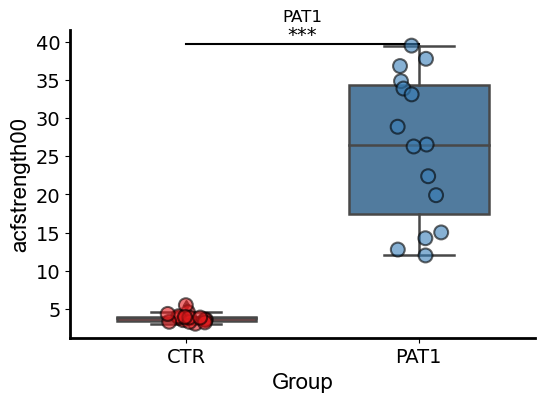

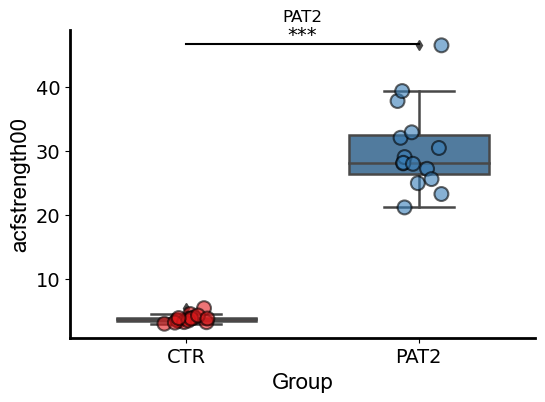

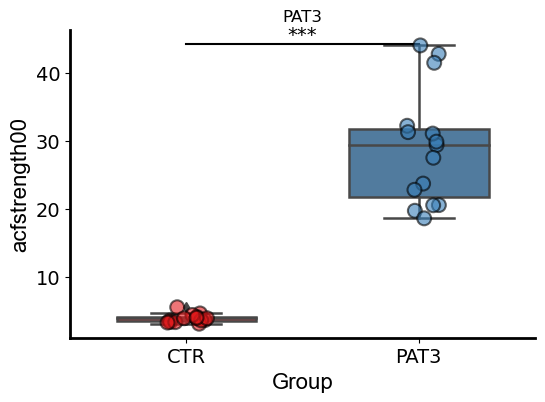

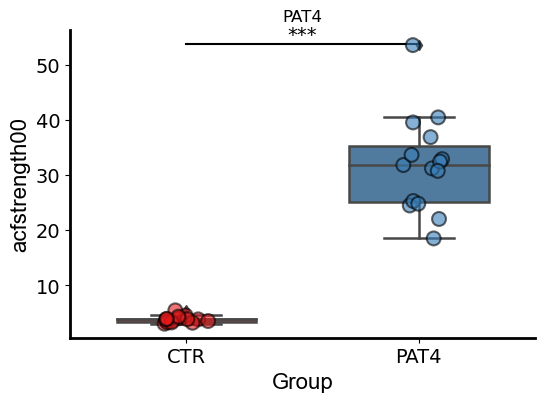

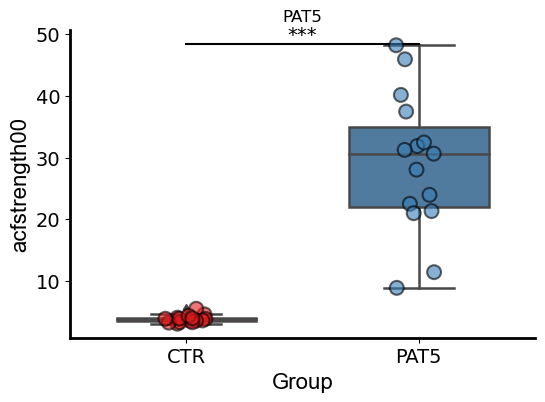

In [ ]:
var = 'acfstrength00'
scan_times2 = ['PAT1','PAT2','PAT3','PAT4','PAT5']
ctl_global_df = global_int_df[global_int_df['Time_of_Scan'] == 'CTR']
for scantime in scan_times2:
    pat_global_df = global_int_df[global_int_df['Time_of_Scan'] == scantime]
    tvalue, pvalue = stats.ttest_ind(pat_global_df[var], ctl_global_df[var]) 
    print('==>', scantime, tvalue, pvalue)
    
    new_df = pd.concat((ctl_global_df,pat_global_df))
# new_df
    if pvalue < 0.5:
        
        fig, ax = plt.subplots(figsize=(6, 4))
        ax = sns.stripplot(x= 'Time_of_Scan',
                           y= var,
                          jitter= True,
                          palette="Set1",
                          data = new_df,
                          size = 10,
                          edgecolor = 'k',
                          linewidth = 1.5,
                          alpha =0.6
                         )
        sns.boxplot(ax = ax, 
                    x= 'Time_of_Scan',
                    y= var,
                    palette='Set1',
                    width = 0.6,
                    saturation = 0.6,
                    linewidth = 1.8,
                    data = new_df)

        y_max = new_df[var].max()
        add_sig_star(0, 1, y_max + 0.2, 0.05, pvalue, ax)  # W1 vs W2
        ax.set_title(scantime)
        ax.set_xlabel('Group',fontsize = 16, font = 'arial')
        ax.set_ylabel(var, fontsize = 16,font = 'arial')
        plt.xticks(fontsize= 14)
        plt.yticks(fontsize= 14)
        # ax.set_yticks(np.arange(-4,3,1),fontsize = 16, font = 'arial')
        # ax.set_xticks(['CTR','PAT1','PAT2','PAT3','PAT4','PAT5'],fontsize = 16, font = 'arial')
        # plt.grid()
        font_prop = font_manager.FontProperties(size=12)
        # ax.legend(prop = font_prop)
        bwith = 2 
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_linewidth(bwith)
        ax.spines['left'].set_linewidth(bwith)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6432\427312408.py:40: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  ax = sns.stripplot(x= 'Time_of_Scan',


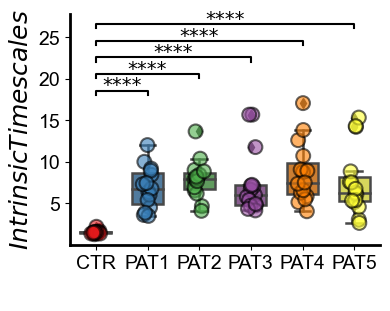

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp
import matplotlib.font_manager as font_manager
import numpy as np

var = 'INT_{0}'
Ctr = global_int_df[global_int_df['Time_of_Scan'] == 'CTR'][var]
pat1 = global_int_df[global_int_df['Time_of_Scan'] == 'PAT1'][var]
pat2 = global_int_df[global_int_df['Time_of_Scan'] == 'PAT2'][var]
pat3 = global_int_df[global_int_df['Time_of_Scan'] == 'PAT3'][var]
pat4 = global_int_df[global_int_df['Time_of_Scan'] == 'PAT4'][var]
pat5 = global_int_df[global_int_df['Time_of_Scan'] == 'PAT5'][var]
tvalue, p1 = stats.ttest_ind(Ctr,pat1)
tvalue, p2 = stats.ttest_ind(Ctr,pat2)
tvalue, p3 = stats.ttest_ind(Ctr,pat3)
tvalue, p4 = stats.ttest_ind(Ctr,pat4)
tvalue, p5 = stats.ttest_ind(Ctr,pat5)


def add_sig_star(x1, x2, y, h, p_val, ax):
    bar_x = [x1, x1, x2, x2]
    bar_y = [y, y+h, y+h, y]
    ax.plot(bar_x, bar_y, c='black', linewidth=1.5)
    if p_val < 0.0001:
        text = '****'
    elif p_val < 0.001:
        text = '**'
    elif p_val < 0.01:
        text = '**'
    elif p_val < 0.05:
        text = '*'
    else:
        text = 'ns'
    ax.text((x1 + x2) * 0.5, y , text, ha='center', va='bottom', fontsize=14)


fig, ax = plt.subplots(figsize=(4, 3))
ax = sns.stripplot(x= 'Time_of_Scan',
                   y= var,
                   # hue= ' ', 
                  jitter= True,
                  palette="Set1",
                  data = global_int_df,
                  size = 10,
                  edgecolor = 'k',
                  linewidth = 1.5,
                  alpha =0.6
                 )
sns.boxplot(ax = ax, 
            x= 'Time_of_Scan',
                   y= var,
            palette='Set1',
            width = 0.6,
            saturation = 0.6,
            linewidth = 1.8,
            data = global_int_df)

y_max = global_int_df[var].max()

add_sig_star(0, 1, y_max + 1, 0.5, p1, ax)  # W1 vs W2
add_sig_star(0, 2, y_max + 3, 0.5, p2, ax)  # W2 vs W3
add_sig_star(0, 3, y_max + 5, 0.5, p3, ax)  # W2 vs W3
add_sig_star(0, 4, y_max + 7, 0.5, p4, ax)  # W2 vs W3
add_sig_star(0, 5, y_max + 9, 0.5, p5, ax)  # W2 vs W3

# ax.set_itle('Dynamics of Hub Regions: Slaves Vs. Master ')
fonts = 16
ax.set_xlabel(' ',fontsize = fonts+2,  family ='Arial')
ax.set_ylabel(f'$Intrinsic Timescales$', fontsize = fonts+2, family ='Arial')
plt.xticks(fontsize= 14,family ='Arial')
plt.yticks(fontsize= 14,family ='Arial')

font_prop = font_manager.FontProperties(size=12)
# ax.legend(prop = font_prop)
bwith = 2 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_linewidth(bwith)
ax.spines['left'].set_linewidth(bwith)

plt.savefig(f'net_{var}.png', dpi = 400, bbox_inches='tight')

In [271]:
global_int_df

,Subj,Time_of_Scan,INT_{0},INT_{0.1},INT_{0.5},ACF_{0},ACF_{0.1},ACF_{0.5},ac1
0,0,CTR,1.448699,1.422717,1.082604,3.530938,3.108125,1.977813,0.846588
1,1,CTR,1.650556,1.604116,1.128074,4.579063,3.688438,2.078750,0.851024
2,2,CTR,1.527095,1.503615,1.162163,3.851875,3.333750,2.029375,0.850803
3,3,CTR,2.167078,2.122382,1.613995,5.489687,4.631562,2.553438,0.891721
4,4,CTR,1.518476,1.499057,1.172900,3.598125,3.210625,2.051875,0.855183
...,...,...,...,...,...,...,...,...,...
85,10,PAT5,2.630293,2.207510,1.413675,8.878438,5.540938,2.631563,0.700415
86,11,PAT5,7.505398,6.513032,2.176066,32.443438,20.326875,4.091250,0.454908
87,12,PAT5,5.377105,4.537107,1.373742,21.321563,13.622500,2.565937,0.618793
88,13,PAT5,6.734221,5.694987,1.458277,28.039688,18.699063,2.869688,0.672462
